# 02 · A1 core benchmark — `cnamuangtoun/resume-job-description-fit`

The dataset every stage of the matching progression is trained and scored on. This
notebook covers the three findings that change how it must be used: the effective sample
size, the resume leakage in the shipped split, and the relevance density that makes
Recall@10 unreachable.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from candidate_screener.config import DOCS_DATA, RAW, MANIFEST, PROFILE_METRICS
from candidate_screener.data.profile import load_split
from candidate_screener.data.sources import SOURCES

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

METRICS = json.loads(PROFILE_METRICS.read_text())["checks"]
print("profile metrics generated:", json.loads(PROFILE_METRICS.read_text())["generated"])

profile metrics generated: 2026-08-19T11:44:13+00:00


In [2]:
train, test = load_split("fit", "train"), load_split("fit", "test")
print(train.shape, test.shape, list(train.columns))
train.head(3)

(6241, 3) (1759, 3) ['resume_text', 'job_description_text', 'label']


,resume_text,job_description_text,label
0,SummaryHighly motivated Sales Associate with extensive customer service and sales expe...,Net2Source Inc. is an award-winning total workforce solutions company recognized by St...,No Fit
1,Professional SummaryCurrently working with Caterpillar as an contract employee Active ...,At Salas OBrien we tell our clients that were engineered for impact. This passion for ...,No Fit
2,"SummaryI started my construction career in June of 2017 in Jacksonville, Florida as an...",Schweitzer Engineering Laboratories (SEL) Infrastructure Defense Division seeks a tale...,No Fit


## Label mix — balanced enough that Macro-F1 is a fair headline metric

,train,test
No Fit,0.5036,0.4872
Potential Fit,0.2493,0.2524
Good Fit,0.2471,0.2604


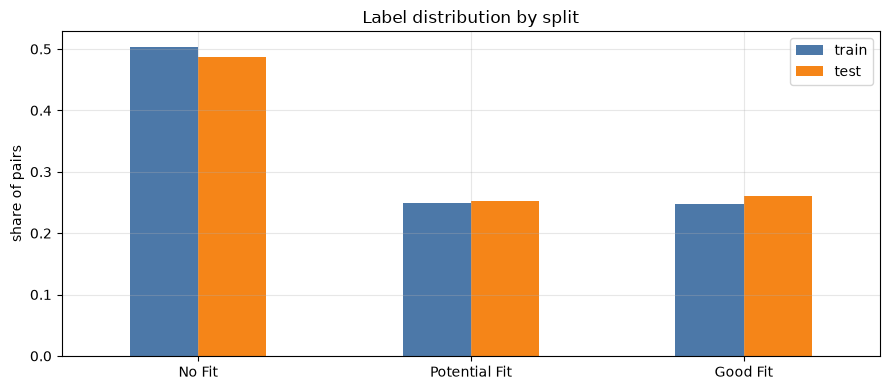

In [3]:
mix = pd.DataFrame({s: m["label_share"] for s, m in METRICS["fit"]["splits"].items()})
ax = mix.plot.bar(rot=0, color=["#4C78A8", "#F58518"])
ax.set_ylabel("share of pairs"); ax.set_title("Label distribution by split")
plt.tight_layout(); mix

## Leakage — the shipped split is JD-disjoint, not candidate-disjoint

§5.2 of the proposal commits to a candidate-level split. The shipped split does not
deliver one.

In [4]:
shared = set(train.resume_text) & set(test.resume_text)
print(f"test resumes also present in train: {len(shared)} / {test.resume_text.nunique()}"
      f"  ({100 * len(shared) / test.resume_text.nunique():.1f}%)")
print("JDs shared across splits:", len(set(train.job_description_text) & set(test.job_description_text)))
print("exact (resume, JD) pairs shared:",
      len(set(map(tuple, train[['resume_text', 'job_description_text']].values)) &
          set(map(tuple, test[['resume_text', 'job_description_text']].values))))

test resumes also present in train: 476 / 477  (99.8%)
JDs shared across splits: 0
exact (resume, JD) pairs shared: 0


A fine-tuned cross-encoder will have memorised essentially every test resume. Decision
**D8**: replace this split with the doubly-disjoint re-split described in action plan §3.2,
and state that results are not comparable to published numbers on the shipped split.

## Relevance density — why Recall@10 is the wrong metric here

count    28.0
mean     16.4
std      12.7
min       1.0
25%       3.0
50%      18.0
75%      24.2
max      48.0
dtype: float64

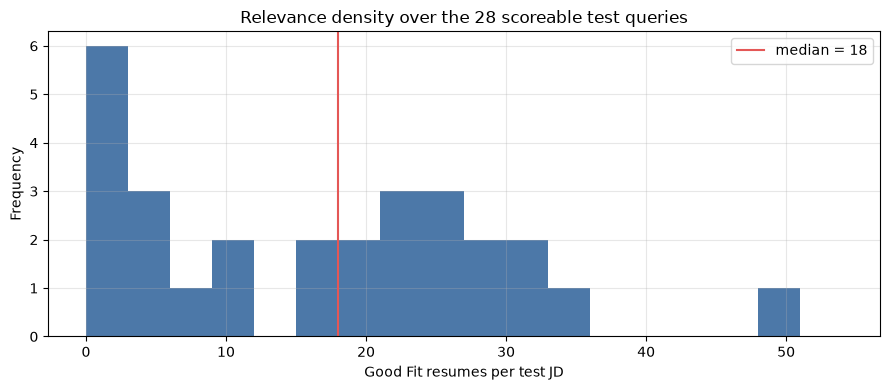

In [5]:
good = test[test.label == "Good Fit"].groupby("job_description_text").size()
ax = good.plot.hist(bins=range(0, 55, 3), color="#4C78A8")
ax.axvline(good.median(), color="#E45756", label=f"median = {good.median():.0f}")
ax.set_xlabel("Good Fit resumes per test JD"); ax.legend()
ax.set_title(f"Relevance density over the {len(good)} scoreable test queries")
plt.tight_layout()
good.describe().round(1)

In [6]:
ks = [5, 10, 20, 50, 100]
ceiling = pd.DataFrame({
    "queries where Recall@k >= 0.90 is reachable": [f"{100 * (good <= k / 0.9).mean():.0f}%" for k in ks],
    "median query's Recall@k ceiling": [f"{min(1.0, k / good.median()):.2f}" for k in ks],
}, index=[f"k={k}" for k in ks])
ceiling

,queries where Recall@k >= 0.90 is reachable,median query's Recall@k ceiling
k=5,32%,0.28
k=10,43%,0.56
k=20,61%,1.00
k=50,100%,1.00
k=100,100%,1.00


A query with 18 relevant documents cannot exceed Recall@10 = 10/18 = 0.56. The proposal's
">90% Recall@10" target is therefore unreachable for 57% of queries **by construction**,
independent of model quality.

Adopted metric set (decision **D9**): **Recall@50, Precision@10, nDCG@10**, each reported
with *n* and a bootstrap confidence interval.

## Read the labels yourself — the calibration step behind decision D2

In [7]:
def show(row, chars=700):
    print(f"===== label: {row.label}")
    print("--- JD  :", row.job_description_text[:chars].replace("\n", " "), "...")
    print("--- CV  :", row.resume_text[:chars].replace("\n", " "), "...\n")

sample = pd.concat([test[test.label == lab].head(1) for lab in
                    ["Good Fit", "Potential Fit", "No Fit"]])
for _, row in sample.iterrows():
    show(row)

===== label: Good Fit
--- JD  : Position Type  Full time  Type Of Hire  Experienced (relevant combo of work and education)  Education Desired  Bachelor of Computer Engineering  Travel Percentage  0%  Job Description  We are FIS. Our technology powers the worlds economy and our teams bring innovation to life. We champion diversity to deliver the best products and solutions for our colleagues, clients, and communities. If youre ready to start learning, growing, and making an impact with a career in fintech, wed like to know~ Are you FIS?  About The Role  FIS provides a leading in-house payment management platform (SaaS - Software as a Service) that serves high-volume merchants such as Netflix, Overstock.com, GoDaddy, and man ...
--- CV  : Professional SummarySeeking Challenging and Rewarding Assignments with a growth Oriented Organization My Role Worked on Hybrid driven framework in WebDriver and Page Object Model. Good knowledge of creating xpath to find dynamic objects. Good knowledge 

Judge for yourselves whether the distinctions are defensible. 6 pairs in the corpus carry
**conflicting labels**, so these are annotations, not ground truth — the argument for
treating >85% Macro-F1 as an unrealistic ceiling.